# ch317 — Recurrent Neural Networks

## 1. Sequences and temporal dependencies

A feed-forward MLP maps a fixed-size input to output — it cannot handle sequences of
variable length or carry information across time steps.

A **Recurrent Neural Network** (RNN) processes one element at a time and maintains a
hidden state $h_t$ that summarises the sequence so far:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$
$$y_t = W_y h_t + b_y$$

The same weight matrices $W_h, W_x$ are used at every time step — **weight sharing over time**,
analogous to spatial weight sharing in CNNs.

*(Function composition: ch054. Dynamical systems: ch079.)*

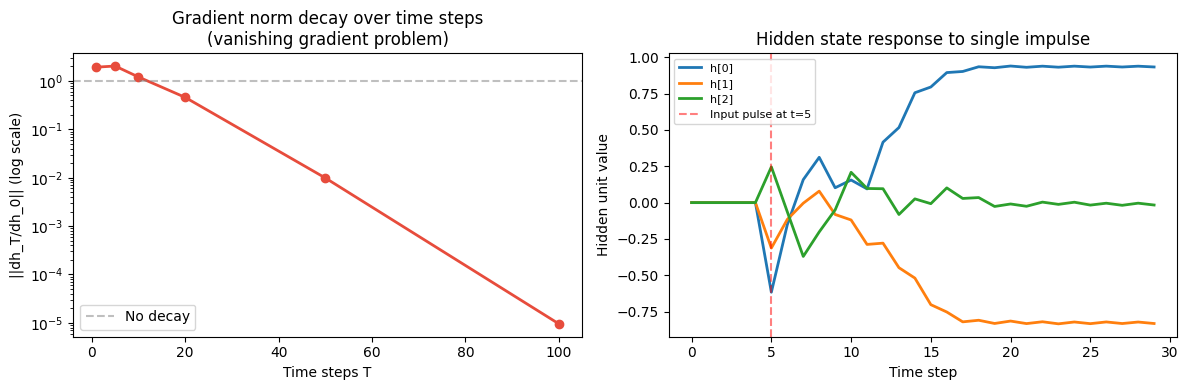

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class VanillaRNN:
    """Vanilla RNN cell. Input → hidden → output."""

    def __init__(self, input_dim: int, hidden_dim: int,
                 output_dim: int, seed: int = 0):
        rng = np.random.default_rng(seed)
        self.H = hidden_dim
        s = 1.0 / np.sqrt(hidden_dim)
        self.W_h = rng.normal(0, s, (hidden_dim, hidden_dim))
        self.W_x = rng.normal(0, s, (hidden_dim, input_dim))
        self.b_h = np.zeros(hidden_dim)
        self.W_y = rng.normal(0, s, (output_dim, hidden_dim))
        self.b_y = np.zeros(output_dim)

    def step(self, x: np.ndarray, h_prev: np.ndarray) -> tuple:
        """Single time step. x: (input_dim,). Returns (h, y)."""
        h = np.tanh(self.W_h @ h_prev + self.W_x @ x + self.b_h)
        y = self.W_y @ h + self.b_y
        return h, y

    def forward(self, X: np.ndarray) -> tuple:
        """X: (T, input_dim). Returns (ys, hs)."""
        h = np.zeros(self.H)
        hs, ys = [h], []
        for x in X:
            h, y = self.step(x, h)
            hs.append(h); ys.append(y)
        return np.array(ys), np.array(hs)


# ── Gradient through time: vanishing problem ──
rng = np.random.default_rng(42)
T_steps = [1, 5, 10, 20, 50, 100]
H = 64; D = 4

rnn = VanillaRNN(D, H, 1, seed=0)
X_seq = rng.normal(0, 1, (max(T_steps), D))

# Simulate gradient norm decay: how much does gradient at step 0
# contribute to output at step T?
def gradient_norm_at_step(rnn, T, x_seq, h0=None):
    if h0 is None: h0 = np.zeros(rnn.H)
    h = h0; hs = [h]
    for t in range(T):
        h = np.tanh(rnn.W_h @ h + rnn.W_x @ x_seq[t] + rnn.b_h)
        hs.append(h.copy())

    # Jacobian product: dh_T/dh_0 (approximate by norm of product of Jacobians)
    J = np.eye(rnn.H)
    for t in range(T):
        diag = 1 - hs[t+1]**2  # tanh derivative
        J = (rnn.W_h * diag[:, None]) @ J
    return float(np.linalg.norm(J, ord=2))

grad_norms = [gradient_norm_at_step(rnn, t, X_seq) for t in T_steps]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.semilogy(T_steps, grad_norms, 'o-', color='#e74c3c', lw=2)
ax1.set_title('Gradient norm decay over time steps\n(vanishing gradient problem)')
ax1.set_xlabel('Time steps T'); ax1.set_ylabel('||dh_T/dh_0|| (log scale)')
ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='No decay')
ax1.legend()

# Hidden state dynamics for a simple sequence
T_demo = 30
x_pulse = np.zeros((T_demo, 1))
x_pulse[5, 0] = 1.0  # a single impulse at t=5
rnn_1d = VanillaRNN(1, 8, 1, seed=3)
ys, hs = rnn_1d.forward(x_pulse)

ax2.plot(hs[1:, 0], label='h[0]', lw=2)
ax2.plot(hs[1:, 1], label='h[1]', lw=2)
ax2.plot(hs[1:, 2], label='h[2]', lw=2)
ax2.axvline(5, color='red', linestyle='--', alpha=0.5, label='Input pulse at t=5')
ax2.set_title('Hidden state response to single impulse')
ax2.set_xlabel('Time step'); ax2.set_ylabel('Hidden unit value')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ch317_rnn.png', dpi=120)
plt.show()

## 2. Backpropagation Through Time (BPTT)

To train an RNN, we unroll it across $T$ time steps and apply backprop.
The gradient of the loss with respect to $W_h$ sums contributions from all steps:

$$\frac{\partial \mathcal{L}}{\partial W_h} = \sum_t \frac{\partial \mathcal{L}}{\partial h_t} \frac{\partial h_t}{\partial W_h}$$

The key recursion:

$$\frac{\partial \mathcal{L}}{\partial h_t} = \frac{\partial \mathcal{L}}{\partial h_{t+1}} W_h^\top \cdot \text{diag}(1 - h_{t+1}^2) + \frac{\partial \mathcal{L}_{t}}{\partial h_t}$$

The $W_h^\top$ term appears $T-t$ times in the gradient from step $T$ back to step $t$.
If $\|W_h^\top\| < 1$, gradients vanish; if $\|W_h^\top\| > 1$, they explode.

**Truncated BPTT**: stop gradient after $k$ steps — a practical solution to long sequences.

## 3. Summary

- RNNs process sequences by maintaining a hidden state $h_t = \tanh(W_h h_{t-1} + W_x x_t)$.
- Same weights at every step: weight sharing over time, like spatial weight sharing in CNNs.
- BPTT: unroll, apply chain rule, sum gradients over time.
- Vanishing/exploding gradients: products of $W_h$ across $T$ steps shrink or blow up.
- LSTM and GRU *(ch318)* are the engineering solution to this mathematical problem.

## 4. Forward and backward references

**Used here:** tanh activation *(ch309)*, chain rule *(ch215)*, matrix products *(ch153)*.

**This will reappear in ch318 — LSTM and GRU**, which solve the vanishing gradient problem
with gating mechanisms, and in ch336 — Project: Character-Level LM.